In [1]:
!nvidia-smi
import torch
print(f'CUDA disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
else:
    print('⚠️ Activez le GPU : Exécution > Modifier le type exécution > GPU T4')


Fri May 29 10:45:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

# These are general dependencies, keep them here.
!pip install -q opencv-python-headless
!pip install -q scikit-image scipy
!pip install -q requests Pillow numpy
print('✅ Dépendances de base installées')

✅ Dépendances de base installées


In [3]:
# This cell is no longer needed as torchvision is handled by the main FIX cell (g9u1vdmYpP82).
pass

In [4]:
!pip install -q opencv-python-headless
!pip install -q scikit-image scipy
!pip install -q requests Pillow numpy
print('✅ Dépendances de base installées')

✅ Dépendances de base installées


In [5]:
# This cell is no longer needed as `torch` and GAN-related libraries are handled by the main FIX cell (g9u1vdmYpP82).
pass

In [6]:
# This cell is no longer needed as GAN-related libraries are handled by the main FIX cell (g9u1vdmYpP82).
pass

In [7]:
# fastai is now installed by the main FIX cell (g9u1vdmYpP82).
# This cell now only handles cloning DeOldify and adding it to the system path.
!git clone -q https://github.com/jantic/DeOldify.git
import sys
sys.path.insert(0, '/content/DeOldify')
print('✅ DeOldify cloné et ajouté au path')

✅ DeOldify cloné et ajouté au path


In [8]:
!pip install -q torchvision
print('✅ Torchvision installé')

✅ Torchvision installé


In [9]:
# This cell's content for fastai install, DeOldify clone, and fastai patch has been moved
# to the main FIX cell (g9u1vdmYpP82) and the previous DeOldify clone cell.
# It is now made inactive.
pass

In [10]:
import os
os.makedirs('/content/DeOldify/models', exist_ok=True)

print('📥 Téléchargement DeOldify Artistic (GAN)...')
!wget -q --show-progress -O /content/DeOldify/models/ColorizeArtistic_gen.pth \
    'https://data.deepai.org/deoldify/ColorizeArtistic_gen.pth'

print('📥 Téléchargement DeOldify Stable (GAN)...')
!wget -q --show-progress -O /content/DeOldify/models/ColorizeStable_gen.pth \
    'https://huggingface.co/spensercai/DeOldify/resolve/main/ColorizeStable_gen.pth'

# ── Vérifier les tailles (doivent être > 100MB) ───────────────
import os
for f in ['ColorizeArtistic_gen.pth', 'ColorizeStable_gen.pth']:
    path = f'/content/DeOldify/models/{f}'
    size = os.path.getsize(path) / (1024*1024)
    status = '✅' if size > 100 else '❌ CORROMPU'
    print(f'{status} {f} : {size:.1f} MB')

📥 Téléchargement DeOldify Artistic (GAN)...
/content/DeOldify/m 100%[===================>] 243.32M  4.91MB/s    in 49s     
📥 Téléchargement DeOldify Stable (GAN)...
/content/DeOldify/m 100%[===================>] 833.57M  94.9MB/s    in 4.9s    
✅ ColorizeArtistic_gen.pth : 243.3 MB
✅ ColorizeStable_gen.pth : 833.6 MB


In [11]:
os.makedirs('models/weights', exist_ok=True)

print('📥 Real-ESRGAN x4...')
!wget -q --show-progress -O models/weights/RealESRGAN_x4plus.pth \
    https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth

print('📥 GFPGAN v1.4...')
!wget -q --show-progress -O models/weights/GFPGANv1.4.pth \
    https://github.com/TencentARC/GFPGAN/releases/download/v1.3.4/GFPGANv1.4.pth

print('📥 Modèles détection visages...')
!wget -q -O models/weights/detection_Resnet50_Final.pth \
    https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth
!wget -q -O models/weights/parsing_parsenet.pth \
    https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth

print('✅ Tous les modèles de restauration téléchargés')

📥 Real-ESRGAN x4...
models/weights/Real 100%[===================>]  63.93M  --.-KB/s    in 0.1s    
📥 GFPGAN v1.4...
models/weights/GFPG 100%[===================>] 332.48M   302MB/s    in 1.1s    
📥 Modèles détection visages...
✅ Tous les modèles de restauration téléchargés


In [12]:
!sudo apt-get update && sudo apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time
subprocess.Popen(['ollama', 'serve'],
                 stdout=subprocess.DEVNULL,
                 stderr=subprocess.DEVNULL)
time.sleep(5)
print('🚀 Serveur Ollama démarré')

print('📥 Téléchargement LLaVA 7B (LLM Vision ~4GB, patientez 5-10 min)...')
!ollama pull llava:7b
print('✅ LLaVA (LLM) prêt')

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,696 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,030 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu j

In [13]:
import os

# Install zstd dependency for ollama
!sudo apt-get update && sudo apt-get install -y zstd

!curl -fsSL https://ollama.com/install.sh | sh

import subprocess, time
subprocess.Popen(['ollama', 'serve'],
                 stdout=subprocess.DEVNULL,
                 stderr=subprocess.DEVNULL)
time.sleep(5)
print('🚀 Serveur Ollama démarré')

print('📥 Téléchargement LLaVA 7B (LLM Vision ~4GB, patientez 5-10 min)...')
!ollama pull llava:7b
print('✅ LLaVA (LLM) prêt')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [14]:
# ============================================================
# 🔧 COMPREHENSIVE FIX Real-ESRGAN + GFPGAN + DeOldify + Gradio
# Compatible Google Colab 2026 - RUN THIS FIRST AND RESTART!
# ============================================================

# --- Step 0: Upgrade pip, setuptools, and wheel (to prevent metadata errors) ---
print('Upgrading pip, setuptools, and wheel...')
!pip install --upgrade pip setuptools wheel -q

# --- Step 1: Clean up all potentially conflicting packages ---
print('Uninstalling conflicting packages...')
!pip uninstall -y basicsr realesrgan gfpgan facexlib torchvision torch fastai gradio gradio-client hf-gradio huggingface_hub numpy -q

# --- Step 2: Install specific compatible versions ---
print('Installing core compatible versions...')
!pip install -q \
torch==2.2.0 \
torchvision==0.17.0 \
fastai==2.7.15 \
basicsr==1.4.2 \
facexlib==0.3.0 \
gfpgan==1.3.8 \
realesrgan==0.3.0 \
numpy==1.26.4

# --- Step 3: Apply `basicsr` patch (for torchvision.transforms.functional_tensor issue) ---
print('Applying basicsr patch...')
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms import functional as TF/g' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py
!sed -i 's/rgb_to_grayscale(img)/TF.rgb_to_grayscale(img)/g' /usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py

print("Core packages installed and basicsr patch applied.")
print("""
IMPORTANT: You MUST RESTART THE RUNTIME NOW!
Go to 'Runtime' > 'Restart session' in the menu.
""")

# After restarting, run all cells from 'IE5lmHSfoip6' downwards sequentially.

Upgrading pip, setuptools, and wheel...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 64.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cu128 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.
Uninstalling conflicting packages...
Installing core compatible versions...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the package

In [18]:
import sys
!{sys.executable} -m pip install -q torchvision --no-cache-dir
print('✅ Installation terminée — REDÉMARRE LA SESSION !')

✅ Installation terminée — REDÉMARRE LA SESSION !


In [1]:
import torchvision
print(f'✅ Torchvision : {torchvision.__version__}')

✅ Torchvision : 0.17.0+cu121


In [2]:
# This cell's content (basicsr patch) has been moved to the main FIX cell (g9u1vdmYpP82).
# It is now made inactive.
pass

In [3]:
# ── Patch basicsr : functional_tensor supprimé dans torchvision récent ──
import os

filepath = '/usr/local/lib/python3.12/dist-packages/basicsr/data/degradations.py'

with open(filepath, 'r') as f:
    content = f.read()

# Remplacer l'ancien import par le nouveau
content = content.replace(
    'from torchvision.transforms.functional_tensor import rgb_to_grayscale',
    'from torchvision.transforms.functional import rgb_to_grayscale'
)

with open(filepath, 'w') as f:
    f.write(content)

print('✅ Patch basicsr appliqué')

✅ Patch basicsr appliqué


In [4]:
import torch
print(torch.__version__)
!pip index versions torchvision

2.2.0+cu121
torchvision (0.27.0)
Available versions: 0.27.0, 0.26.0, 0.25.0, 0.24.1, 0.24.0, 0.23.0, 0.22.1, 0.22.0, 0.21.0, 0.20.1, 0.20.0, 0.19.1, 0.19.0, 0.18.1, 0.18.0, 0.17.2, 0.17.1, 0.17.0
  INSTALLED: 0.17.0
  LATEST:    0.27.0


In [5]:
import cv2
import numpy as np
from PIL import Image, ImageEnhance
import torch
import warnings
warnings.filterwarnings('ignore')

# ── Real-ESRGAN ───────────────────────────────────────────────
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

print('🔄 Chargement Real-ESRGAN (GAN)...')
esrgan_net = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                     num_block=23, num_grow_ch=32, scale=4)
esrgan_upsampler = RealESRGANer(
    scale=4,
    model_path='models/weights/RealESRGAN_x4plus.pth',
    model=esrgan_net,
    tile=400,
    tile_pad=10,
    pre_pad=0,
    half=torch.cuda.is_available()
)
print('✅ Real-ESRGAN chargé')

# ── GFPGAN ────────────────────────────────────────────────────
from gfpgan import GFPGANer

print('🔄 Chargement GFPGAN (GAN)...')
gfpgan_restorer = GFPGANer(
    model_path='models/weights/GFPGANv1.4.pth',
    upscale=2,
    arch='clean',
    channel_multiplier=2,
    bg_upsampler=esrgan_upsampler
)
print('✅ GFPGAN chargé')

🔄 Chargement Real-ESRGAN (GAN)...
✅ Real-ESRGAN chargé
🔄 Chargement GFPGAN (GAN)...
Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.1.0/detection_Resnet50_Final.pth" to /content/gfpgan/weights/detection_Resnet50_Final.pth



100%|██████████| 104M/104M [00:00<00:00, 193MB/s] 


Downloading: "https://github.com/xinntao/facexlib/releases/download/v0.2.2/parsing_parsenet.pth" to /content/gfpgan/weights/parsing_parsenet.pth



100%|██████████| 81.4M/81.4M [00:00<00:00, 218MB/s]


✅ GFPGAN chargé


In [6]:
!pip install -q ffmpeg-python
!pip install -q yt-dlp

In [11]:
import sys

# ── Upgrader setuptools (contient pkg_resources corrigé) ─────
!{sys.executable} -m pip install -q --upgrade setuptools==69.5.1

# ── Recharger ─────────────────────────────────────────────────
for mod in list(sys.modules.keys()):
    if 'pkg_resources' in mod or 'setuptools' in mod:
        del sys.modules[mod]

import pkg_resources
print(f'✅ pkg_resources OK : {pkg_resources.__version__}')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


AttributeError: module 'pkg_resources' has no attribute '__version__'

In [13]:
import os, sys, torch
import warnings
warnings.filterwarnings('ignore')

os.chdir('/content/DeOldify')
sys.path.insert(0, '/content/DeOldify')

if not hasattr(torch, '_orig_load'):
    torch._orig_load = torch.load
def _patched_load(f, *args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return torch._orig_load(f, *args, **kwargs)
torch.load = _patched_load

from deoldify import device
from deoldify.device_id import DeviceId          # ✅ séparé
from deoldify.visualize import get_image_colorizer

if torch.cuda.is_available():
    device.set(device=DeviceId.GPU0)             # ✅ correct
    print('🎮 GPU')
else:
    device.set(device=DeviceId.CPU)
    print('💻 CPU')

colorizer_artistic = get_image_colorizer(artistic=True)
colorizer_stable   = get_image_colorizer(artistic=False)
print('✅ DeOldify chargé !')

🎮 GPU


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 132MB/s]
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:01<00:00, 155MB/s]


✅ DeOldify chargé !


In [14]:
def denoise_image(img_pil, strength=10):
    """
    Supprime le bruit (grain, rayures) d'une image ancienne.
    strength : 5 = léger  |  10 = moyen  |  20 = fort
    """
    img_np  = np.array(img_pil.convert('RGB'))
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    denoised = cv2.fastNlMeansDenoisingColored(
        img_bgr, None, strength, strength, 7, 21
    )
    return Image.fromarray(cv2.cvtColor(denoised, cv2.COLOR_BGR2RGB))

print('✅ Fonction denoise_image définie')


✅ Fonction denoise_image définie


In [15]:
def restore_image(img_pil, mode='Faces + Background'):
    """
    Restaure une image avec des modèles GAN.
    mode 'Faces + Background' : GFPGAN (visages) + Real-ESRGAN (fond)
    mode 'Background only'    : Real-ESRGAN uniquement
    """
    img_np  = np.array(img_pil.convert('RGB'))
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    if mode == 'Faces + Background':
        _, _, output_bgr = gfpgan_restorer.enhance(
            img_bgr,
            has_aligned=False,
            only_center_face=False,
            paste_back=True
        )
    else:
        output_bgr, _ = esrgan_upsampler.enhance(img_bgr, outscale=2)

    output_rgb = cv2.cvtColor(output_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(output_rgb)

print('✅ Fonction restore_image définie')


✅ Fonction restore_image définie


In [16]:
def colorize_deoldify(img_pil, style='Artistic', render_factor=35, sat_boost=1.3):
    """
    Colorise une image N&B avec DeOldify (GAN).
    style         : 'Artistic' = couleurs riches  |  'Stable' = tons naturels
    render_factor : 7 (rapide) → 45 (meilleure qualité)
    sat_boost     : booster la saturation après colorisation (1.0 = neutre)
    """
    tmp_path = '/tmp/deoldify_input.jpg'
    img_pil.convert('RGB').save(tmp_path, quality=95)

    colorizer = colorizer_artistic if style == 'Artistic' else colorizer_stable

    result_path = colorizer.plot_transformed_image(
        path=tmp_path,
        render_factor=render_factor,
        compare=False,
        watermarked=False
    )

    colored = Image.open(result_path).convert('RGB')

    # Post-traitement : saturation + contraste
    colored = ImageEnhance.Color(colored).enhance(sat_boost)
    colored = ImageEnhance.Contrast(colored).enhance(1.1)
    colored = ImageEnhance.Sharpness(colored).enhance(1.2)

    return colored

print('✅ Fonction colorize_deoldify définie')


✅ Fonction colorize_deoldify définie


In [17]:
import requests, base64
from io import BytesIO

def describe_with_llava(img_pil, langue='Français', custom_prompt=''):
    """
    Génère une description textuelle de l'image avec LLaVA (LLM).
    Utilise Ollama en local — 100% gratuit, aucune API payante.
    """
    # Encoder l'image en base64
    buf = BytesIO()
    img_pil.save(buf, format='JPEG', quality=85)
    img_b64 = base64.b64encode(buf.getvalue()).decode('utf-8')

    # Choisir le prompt
    if custom_prompt:
        prompt = custom_prompt
    elif langue == 'Français':
        prompt = (
            'Décris cette image ancienne en détail en français. '
            'Mentionne : l époque estimée, les personnes présentes, '
            'le lieu, les objets visibles, et l intérêt historique de cette photo.'
        )
    else:
        prompt = (
            'Describe this old photograph in detail in English. '
            'Mention: estimated era, people present, location, '
            'visible objects, and the historical significance.'
        )

    try:
        r = requests.post(
            'http://localhost:11434/api/generate',
            json={
                'model': 'llava:7b',
                'prompt': prompt,
                'images': [img_b64],
                'stream': False
            },
            timeout=120
        )
        if r.ok:
            return r.json().get('response', 'Pas de réponse')
        return f'Erreur Ollama : {r.status_code}'
    except Exception as e:
        return f'LLaVA non disponible : {e}'

print('✅ Fonction describe_with_llava définie')


✅ Fonction describe_with_llava définie


In [18]:
from PIL import ImageDraw

def make_comparison(img_before, img_after):
    """
    Crée une image côte à côte Avant | Après avec labels.
    """
    # Redimensionner l'original à la taille du résultat
    before = img_before.convert('RGB').resize(img_after.size, Image.LANCZOS)
    after  = img_after.convert('RGB')

    W, H = after.size
    label_h = 36

    def add_label(img, text, color):
        canvas = Image.new('RGB', (W, H + label_h), (20, 20, 20))
        canvas.paste(img, (0, 0))
        draw = ImageDraw.Draw(canvas)
        draw.rectangle([0, H, W, H + label_h], fill=(20, 20, 20))
        draw.text((W // 2 - 30, H + 8), text, fill=color)
        return canvas

    before_labeled = add_label(before, '◀  AVANT', (180, 180, 180))
    after_labeled  = add_label(after,  'APRÈS  ▶', (220, 180, 80))

    sep = Image.new('RGB', (6, H + label_h), (80, 80, 80))

    total_w = W * 2 + 6
    comparison = Image.new('RGB', (total_w, H + label_h), (20, 20, 20))
    comparison.paste(before_labeled, (0, 0))
    comparison.paste(sep, (W, 0))
    comparison.paste(after_labeled, (W + 6, 0))

    return comparison

print('✅ Fonction make_comparison définie')


✅ Fonction make_comparison définie


In [19]:
import traceback

def pipeline(
    img_pil,
    do_denoise,
    denoise_strength,
    do_restore,
    restore_mode,
    do_colorize,
    color_style,
    render_factor,
    sat_boost,
    do_describe,
    langue,
    custom_prompt
):
    if img_pil is None:
        return None, '⚠️ Veuillez charger une image.', None

    logs  = []
    image_originale = img_pil.copy()
    img   = img_pil.convert('RGB')

    try:
        # ── Étape 1 : Débruitage ─────────────────────────────
        if do_denoise:
            logs.append(f'🌫️ Débruitage (force={int(denoise_strength)})...')
            img = denoise_image(img, strength=int(denoise_strength))
            logs.append('✅ Débruitage terminé')

        # ── Étape 2 : Restauration GAN ───────────────────────
        if do_restore:
            logs.append(f'🔧 Restauration GAN ({restore_mode})...')
            img = restore_image(img, mode=restore_mode)
            logs.append('✅ Restauration terminée')

        # ── Étape 3 : Colorisation GAN ───────────────────────
        if do_colorize:
            logs.append(f'🎨 Colorisation DeOldify GAN ({color_style}, render={int(render_factor)})...')
            img = colorize_deoldify(
                img,
                style=color_style,
                render_factor=int(render_factor),
                sat_boost=sat_boost
            )
            logs.append('✅ Colorisation terminée')

        # ── Étape 4 : Comparaison avant/après ────────────────
        comparison = make_comparison(image_originale, img)

        # ── Étape 5 : Description LLM ────────────────────────
        description = ''
        if do_describe:
            logs.append('🤖 Génération description LLaVA (LLM)...')
            description = describe_with_llava(
                img, langue=langue, custom_prompt=custom_prompt
            )
            logs.append('✅ Description générée')

        status = '\n'.join(logs)
        if description:
            status += '\n\n📝 Description :\n' + description

        return img, status, comparison

    except Exception as e:
        err = f'❌ Erreur :\n{traceback.format_exc()}'
        return img_pil, err, None

print('✅ Pipeline principal défini')


✅ Pipeline principal défini


In [20]:
# ================================================================
# CELLULE INSTALLATION — GRADIO
# ================================================================

# Désinstaller les versions conflictuelles
!pip uninstall -q -y gradio gradio-client hf-gradio 2>/dev/null

# Installer gradio 5.x stable + huggingface_hub compatibles
!pip install -q "gradio==5.29.1" "huggingface_hub>=0.23.0"

print("✅ Gradio installé ! IMPORTANT: The FIRST runtime restart happens after the FIX cell (g9u1vdmYpP82).")
print("   If you just ran the FIX cell and restarted, you can now run this cell and subsequent cells.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires pydantic<3.0.0,>=2.12.0, but you have pydantic 2.11.10 which is incompatible.
✅ Gradio installé ! IMPORTANT: The FIRST runtime restart happens after the FIX cell (g9u1vdmYpP82).
   If you just ran the FIX cell and restarted, you can now run this cell and subsequent cells.


In [ ]:
import gradio as gr

CSS = """
@import url('https://fonts.googleapis.com/css2?family=Cormorant+Garamond:wght@700&family=DM+Sans:wght@400;500&display=swap');
body, .gradio-container { font-family:'DM Sans',sans-serif !important; background:#0f0c08 !important; }
.hero { text-align:center; padding:2.5rem 1rem 1.5rem;
        background:radial-gradient(ellipse at top,#3a1a0055 0%,transparent 70%);
        border-bottom:1px solid #5c3010; margin-bottom:1rem; }
.hero h1 { font-family:'Cormorant Garamond',serif !important;
           font-size:2.6rem !important; color:#e8c87a !important;
           letter-spacing:3px; margin:0 !important;
           text-shadow:0 0 40px #c8833a88; }
.hero p  { color:#b08050 !important; margin-top:.6rem !important; }
.tag { display:inline-block; background:#2a1200; border:1px solid #7a4020;
       border-radius:20px; padding:3px 12px; font-size:.78rem; color:#d4905a; margin:3px; }
.stitle { color:#e8c87a !important; font-weight:600;
          border-left:3px solid #c8833a; padding-left:10px; margin:14px 0 6px; }
button.lg.primary { background:linear-gradient(135deg,#7a3010,#c8833a) !important;
    color:#fff !important; border:none !important; font-size:1.05rem !important;
    font-weight:600 !important; letter-spacing:1px !important;
    border-radius:8px !important; transition:all .25s !important; }
button.lg.primary:hover { transform:translateY(-2px) !important;
    box_shadow:0 6px 22px #c8833a55 !important; }
.tips { display:grid; grid-template_columns:repeat(4,1fr); gap:12px;
        padding:1.2rem; margin-top:1rem; background:#150e06;
        border-radius:10px; border:1px solid #3a2010; }
.tip  { color:#e8c87a; }
.tip span { color:#a07040; font-size:.87rem; }
"""

with gr.Blocks(css=CSS, title="Restauration d'Images Anciennes") as demo:

    # ── Hero ──────────────────────────────────────────────────
    gr.HTML("""
    <div class='hero'>
      <h1>🕰️ Restauration d'Images Anciennes</h1>
      <p>Redonnez vie à vos photos historiques grâce aux modèles génératifs (GAN + LLM)</p>
      <div style='margin-top:10px'>
        <span class='tag'>DeOldify GAN</span>
        <span class='tag'>Real-ESRGAN GAN</span>
        <span class='tag'>GFPGAN GAN</span>
        <span class='tag'>LLaVA LLM</span>
        <span class='tag'>100% Gratuit</span>
      </div>
    </div>
    """)

    with gr.Row(equal_height=False):

        # ── Panneau gauche ────────────────────────────────────
        with gr.Column(scale=1, min_width=320):

            gr.HTML('<p class="stitle">📤 Image d\'entrée</p>')
            inp_img = gr.Image(type='pil', label='', height=260)

            gr.HTML('<p class="stitle">🌫️ Étape 1 — Débruitage</p>')
            do_denoise       = gr.Checkbox(label='Activer le débruitage', value=True)
            denoise_strength = gr.Slider(5, 20, value=10, step=1,
                                          label='Force (5=léger, 20=fort)')

            gr.HTML('<p class="stitle">🔧 Étape 2 — Restauration (GAN)</p>')
            do_restore   = gr.Checkbox(label='Activer la restauration', value=True)
            restore_mode = gr.Radio(
                ['Faces + Background', 'Background only'],
                value='Faces + Background',
                label='Mode  (GFPGAN+ESRGAN  |  ESRGAN seul)'
            )

            gr.HTML('<p class="stitle">🎨 Étape 3 — Colorisation (GAN DeOldify)</p>')
            do_colorize   = gr.Checkbox(label='Activer la colorisation', value=True)
            color_style   = gr.Radio(
                ['Artistic', 'Stable'],
                value='Artistic',
                label='Style  (Artistic=vives  |  Stable=naturelles)'
            )
            render_factor = gr.Slider(7, 45, value=35, step=1,
                                       label='Render factor (35=rapide/bon, 45=max qualité)')
            sat_boost     = gr.Slider(1.0, 2.5, value=1.3, step=0.1,
                                       label='Boost saturation')

            gr.HTML('<p class="stitle">🤖 Description IA (LLaVA LLM)</p>')
            do_describe   = gr.Checkbox(label='Générer une description', value=True)
            langue        = gr.Radio(['Français', 'English'], value='Français', label='Langue')
            custom_prompt = gr.Textbox(
                label='Question personnalisée (optionnel)',
                placeholder='Ex: Quel est le contexte historique de cette photo ?',
                lines=2
            )

            btn = gr.Button('✨ Lancer le traitement', variant='primary', size='lg')

        # ── Panneau droit ─────────────────────────────────────
        with gr.Column(scale=2):

            with gr.Tabs():
                with gr.Tab('✨ Image traitée'):
                    out_img = gr.Image(type='pil', label='Résultat final',
                                       height=420, interactive=False)
                with gr.Tab('↔️ Avant / Après'):
                    out_compare = gr.Image(type='pil', label='Comparaison',
                                           height=420, interactive=False)

            gr.HTML('<p class="stitle">📝 Description générée par LLaVA (LLM)</p>')
            out_desc = gr.Textbox(label='', lines=10, interactive=False)

    # ── Conseils ──────────────────────────────────────────────
    gr.HTML("""
    <div class='tips'>
      <div class='tip'><b>📸 Meilleures images</b><br>
        <span>Photos N&B années 1900-1970, portraits, paysages historiques</span></div>
      <div class='tip'><b>🎨 Choisir le style</b><br>
        <span><b>Artistic</b> = couleurs dramatiques<br><b>Stable</b> = tons réalistes</span></div>
      <div class='tip'><b>⚡ Temps estimé</b><br>
        <span>GPU T4 : ~45 sec<br>CPU : 3-5 min</span></div>
      <div class='tip'><b>💡 Max qualité</b><br>
        <span>Render factor = 45<br>Saturation = 1.4</span></div>
    </div>
    """)

    # ── Connexion bouton ──────────────────────────────────────
    btn.click(
        fn=pipeline,
        inputs=[
            inp_img,
            do_denoise, denoise_strength,
            do_restore, restore_mode,
            do_colorize, color_style, render_factor, sat_boost,
            do_describe, langue, custom_prompt
        ],
        outputs=[out_img, out_desc, out_compare]
    )

print('🚀 Lancement de l interface web...')
print('📌 Copier le lien https://xxxx.gradio.live qui apparaît ci-dessous')
demo.launch(share=True, debug=True, show_error=True)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/telemetry/gradio/initiated "HTTP/1.1 200 OK"


HTTP Request: HEAD https://huggingface.co/api/telemetry/gradio/initiated "HTTP/1.1 200 OK"
🚀 Lancement de l interface web...
📌 Copier le lien https://xxxx.gradio.live qui apparaît ci-dessous


INFO:httpx:HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"


HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"


...

HTTP Request: GET https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64 "HTTP/1.1 200 OK"
* Running on public URL: https://36b3a56f722bbcf95e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


INFO:httpx:HTTP Request: HEAD https://36b3a56f722bbcf95e.gradio.live "HTTP/1.1 200 OK"


HTTP Request: HEAD https://36b3a56f722bbcf95e.gradio.live "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/telemetry/gradio/launched "HTTP/1.1 200 OK"


HTTP Request: HEAD https://huggingface.co/api/telemetry/gradio/launched "HTTP/1.1 200 OK"
	Tile 1/4
	Tile 2/4
	Tile 3/4
	Tile 4/4
	Tile 1/4
	Tile 2/4
	Tile 3/4
	Tile 4/4
	Tile 1/4
	Tile 2/4
	Tile 3/4
	Tile 4/4
	Tile 1/4
	Tile 2/4
	Tile 3/4
	Tile 4/4
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/4
	Tile 2/4
	Tile 3/4
	Tile 4/4
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/1
	Tile 1/4
	Tile 2/4
	Tile 3/4
	Tile 4/4


Status: 200, Taille: 35886 bytes
✅ Image téléchargée : (400, 500)
🎨 Test colorisation DeOldify Artistic...
✅ Colorisation OK !


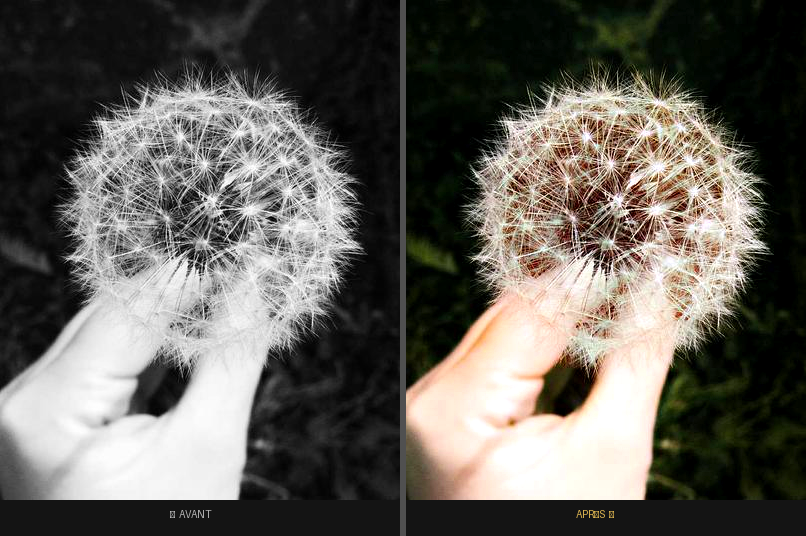

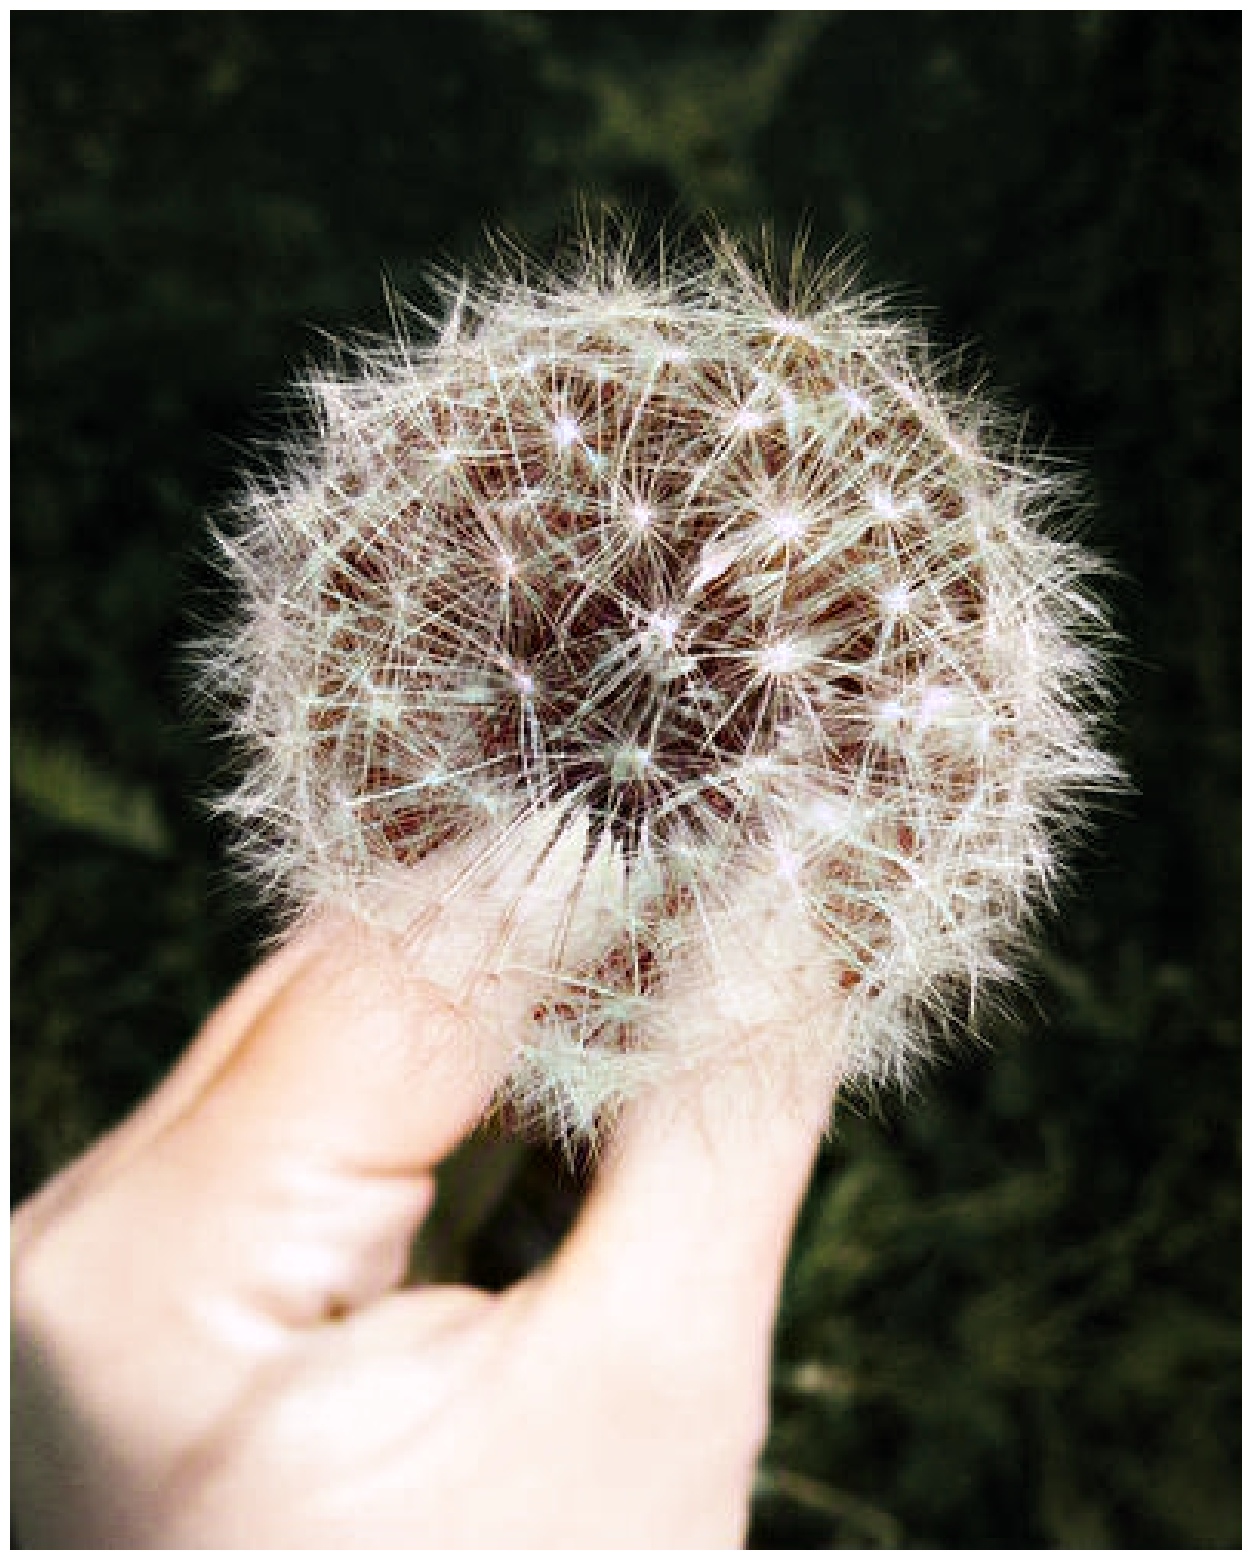

In [ ]:
import requests
from PIL import Image, ImageOps
from io import BytesIO

# ── Image depuis picsum (toujours accessible) ─────────────────
url = 'https://picsum.photos/seed/oldphoto/400/500'
response = requests.get(url, timeout=10)
print(f'Status: {response.status_code}, Taille: {len(response.content)} bytes')
img_test = Image.open(BytesIO(response.content)).convert('RGB')
img_bw   = ImageOps.grayscale(img_test).convert('RGB')  # simuler N&B
print(f'✅ Image téléchargée : {img_test.size}')

print('🎨 Test colorisation DeOldify Artistic...')
result = colorize_deoldify(img_bw, style='Artistic', render_factor=21)
print('✅ Colorisation OK !')

comp = make_comparison(img_bw, result)
display(comp)


In [ ]:
import requests
from PIL import Image
from io import BytesIO

# ── Utiliser l'image picsum téléchargée avant ─────────────────
url = 'https://picsum.photos/seed/oldphoto/400/500'
response = requests.get(url, timeout=10)
img_test = Image.open(BytesIO(response.content)).convert('RGB')

print('🤖 Test LLaVA (LLM)...')
desc = describe_with_llava(img_test, langue='Français')
print('Description générée :')
print(desc)

🤖 Test LLaVA (LLM)...
Description générée :
LLaVA non disponible : HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7bada905dd60>: Failed to establish a new connection: [Errno 111] Connection refused'))
